# Traffic Sign Recognition Using EfficientNet-B0

This project develops a deep learning model for automatic traffic sign classification using the GTSRB (German Traffic Sign Recognition Benchmark) dataset.

An EfficientNet-B0 model pretrained on ImageNet is used with transfer learning and fine-tuning to classify images into 43 traffic sign classes.

## 1. Environment and Libraries

The project uses TensorFlow/Keras for deep learning and pandas and NumPy for data processing.

GPU acceleration is used to speed up model training.

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [11]:
DATASET_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"

import os


['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


## 2. Dataset

The GTSRB dataset contains 43 different traffic sign classes.

The dataset contains 39,209 training images and 12,630 test images. The training data is divided into training and validation sets using a stratified 80:20 split.

In [12]:
import pandas as pd

train_csv = pd.read_csv(os.path.join(DATASET_DIR, "Train.csv"))
test_csv = pd.read_csv(os.path.join(DATASET_DIR, "Test.csv"))

print("Train shape:", train_csv.shape)
print("Test shape:", test_csv.shape)

print("\nTrain columns:")
print(train_csv.columns.tolist())

print("\nFirst train row:")
print(train_csv.iloc[0])

Train shape: (39209, 8)
Test shape: (12630, 8)

Train columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First train row:
Width                                  27
Height                                 26
Roi.X1                                  5
Roi.Y1                                  5
Roi.X2                                 22
Roi.Y2                                 20
ClassId                                20
Path       Train/20/00020_00000_00000.png
Name: 0, dtype: object


In [14]:
from sklearn.model_selection import train_test_split

train_paths = train_csv["Path"].values
train_labels = train_csv["ClassId"].values

test_paths = test_csv["Path"].values
test_labels = test_csv["ClassId"].values

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 31367
Validation: 7842
Test: 12630


## 3. Data Preprocessing

The images are resized to 64 × 64 pixels.

A TensorFlow `tf.data` pipeline is used to load images lazily in batches instead of loading the entire dataset into memory at once.

The data is shuffled, batched, and prefetched for efficient training.

In [17]:
IMG_SIZE = 64
BATCH_SIZE = 32

def load_image(path, label):
    path = tf.strings.join([DATASET_DIR, "/", path])
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = (
    train_ds
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

## 4. EfficientNet-B0 Model

EfficientNet-B0 pretrained on ImageNet is used as the base feature extractor.

The original classification layer is removed and replaced with:
- Global Average Pooling
- Dropout with a rate of 0.3
- A Dense layer with 43 output classes and softmax activation

In [20]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

NUM_CLASSES = 43

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 64, 64, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 64, 64, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 65, 65, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 32, 32,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 32, 32,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 32, 32,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 32, 32,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 32, 32,    │        512 │ block1a_se_excit

 Total params: 4,104,654 (15.66 MB)

 Trainable params: 55,083 (215.17 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 5. Transfer Learning

Initially, the EfficientNet-B0 base model is frozen and only the newly added classification layers are trained.

The model is trained for 5 epochs using the Adam optimizer with a learning rate of 0.001.

In [22]:
EPOCHS_HEAD = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD
)

Epoch 1/5


2026-09-18 10:52:28.241842: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:52:28.375408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:52:28.702754: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:52:28.846410: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:52:29.692096: E external/local_xla/xla/stream_

977/981 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4752 - loss: 1.8678

2026-09-18 10:53:54.563167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:53:54.696215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:53:55.015580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:53:55.159116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:53:56.029038: E external/local_xla/xla/stream_

981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4757 - loss: 1.8658

2026-09-18 10:54:34.651487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:54:34.784705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:54:35.100374: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:54:35.243866: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:54:36.112757: E external/local_xla/xla/stream_

981/981 ━━━━━━━━━━━━━━━━━━━━ 153s 125ms/step - accuracy: 0.5958 - loss: 1.3744 - val_accuracy: 0.7554 - val_loss: 0.8208
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7357 - loss: 0.8342 - val_accuracy: 0.8174 - val_loss: 0.6263
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7735 - loss: 0.7079 - val_accuracy: 0.8516 - val_loss: 0.5239
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7926 - loss: 0.6369 - val_accuracy: 0.8555 - val_loss: 0.4741
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.8026 - loss: 0.5970 - val_accuracy: 0.8729 - val_loss: 0.4327


## 6. Fine-Tuning

After the initial training stage, the EfficientNet-B0 base model is unfrozen so that pretrained features can be adapted to traffic sign images.

Batch Normalization layers are kept frozen for more stable fine-tuning.

A smaller learning rate of 0.0001 is used for another 5 epochs.

In [23]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("EfficientNet-B0 unfrozen for fine-tuning.")

EfficientNet-B0 unfrozen for fine-tuning.


In [24]:
print("Trainable parameters:", sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
))

Trainable parameters: 4020615


In [25]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [26]:
EPOCHS_FINE = 5

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)

Epoch 1/5


2026-09-18 10:59:40.170411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:59:40.307524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:59:40.442936: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:59:44.086149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:59:44.223846: E external/local_xla/xla/stream_

980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8781 - loss: 0.3493

2026-09-18 11:00:30.628710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:00:30.764756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:00:33.842870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:00:33.979670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:00:34.115786: E external/local_xla/xla/stream_

981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 65ms/step - accuracy: 0.9232 - loss: 0.2206 - val_accuracy: 0.9818 - val_loss: 0.0536
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.9807 - loss: 0.0584 - val_accuracy: 0.9872 - val_loss: 0.0421
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9885 - loss: 0.0340 - val_accuracy: 0.9929 - val_loss: 0.0205
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9968 - val_loss: 0.0109
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9939 - loss: 0.0181 - val_accuracy: 0.9911 - val_loss: 0.0291


In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9489 - loss: 0.2237

2026-09-18 11:09:35.661919: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:09:35.795788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:09:36.119390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:09:36.262234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:09:37.096543: E external/local_xla/xla/stream_

395/395 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.9468 - loss: 0.2422
Test Loss: 0.24218055605888367
Test Accuracy: 0.9467933773994446


In [29]:
class_names = {
    0:"Speed limit (20km/h)",
    1:"Speed limit (30km/h)",
    2:"Speed limit (50km/h)",
    3:"Speed limit (60km/h)",
    4:"Speed limit (70km/h)",
    5:"Speed limit (80km/h)",
    6:"End of speed limit (80km/h)",
    7:"Speed limit (100km/h)",
    8:"Speed limit (120km/h)",
    9:"No passing",
    10:"No passing veh > 3.5 tons",
    11:"Right-of-way at intersection",
    12:"Priority road",
    13:"Yield",
    14:"Stop",
    15:"No vehicles",
    16:"Veh > 3.5 tons prohibited",
    17:"No entry",
    18:"General caution",
    19:"Dangerous curve left",
    20:"Dangerous curve right",
    21:"Double curve",
    22:"Bumpy road",
    23:"Slippery road",
    24:"Road narrows on right",
    25:"Road work",
    26:"Traffic signals",
    27:"Pedestrians",
    28:"Children crossing",
    29:"Bicycles crossing",
    30:"Beware of ice/snow",
    31:"Wild animals crossing",
    32:"End speed & passing limits",
    33:"Turn right ahead",
    34:"Turn left ahead",
    35:"Ahead only",
    36:"Go straight or right",
    37:"Go straight or left",
    38:"Keep right",
    39:"Keep left",
    40:"Roundabout mandatory",
    41:"End of no passing",
    42:"End no passing veh > 3.5 tons"
}

NUM_CLASSES = 43

print("Class names loaded:", len(class_names))

Class names loaded: 43


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated:", len(y_pred))

## 7. Model Evaluation

The final model is evaluated on the unseen GTSRB test set.

Accuracy, precision, recall, F1-score, and the confusion matrix are used to evaluate classification performance.

In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=[class_names[i] for i in range(NUM_CLASSES)]
))

                               precision    recall  f1-score   support

         Speed limit (20km/h)       0.74      0.85      0.79        60
         Speed limit (30km/h)       0.99      0.94      0.96       720
         Speed limit (50km/h)       0.91      0.96      0.93       750
         Speed limit (60km/h)       0.96      0.93      0.95       450
         Speed limit (70km/h)       0.99      0.90      0.95       660
         Speed limit (80km/h)       0.92      0.91      0.91       630
  End of speed limit (80km/h)       0.96      1.00      0.98       150
        Speed limit (100km/h)       0.97      0.92      0.95       450
        Speed limit (120km/h)       0.80      0.96      0.87       450
                   No passing       0.99      0.98      0.98       480
    No passing veh > 3.5 tons       0.99      0.99      0.99       660
 Right-of-way at intersection       0.93      0.98      0.95       420
                Priority road       1.00      0.99      0.99       690
     

## 8. Training Performance

The training and validation accuracy and loss are visualized across both training stages to observe model learning and fine-tuning performance.

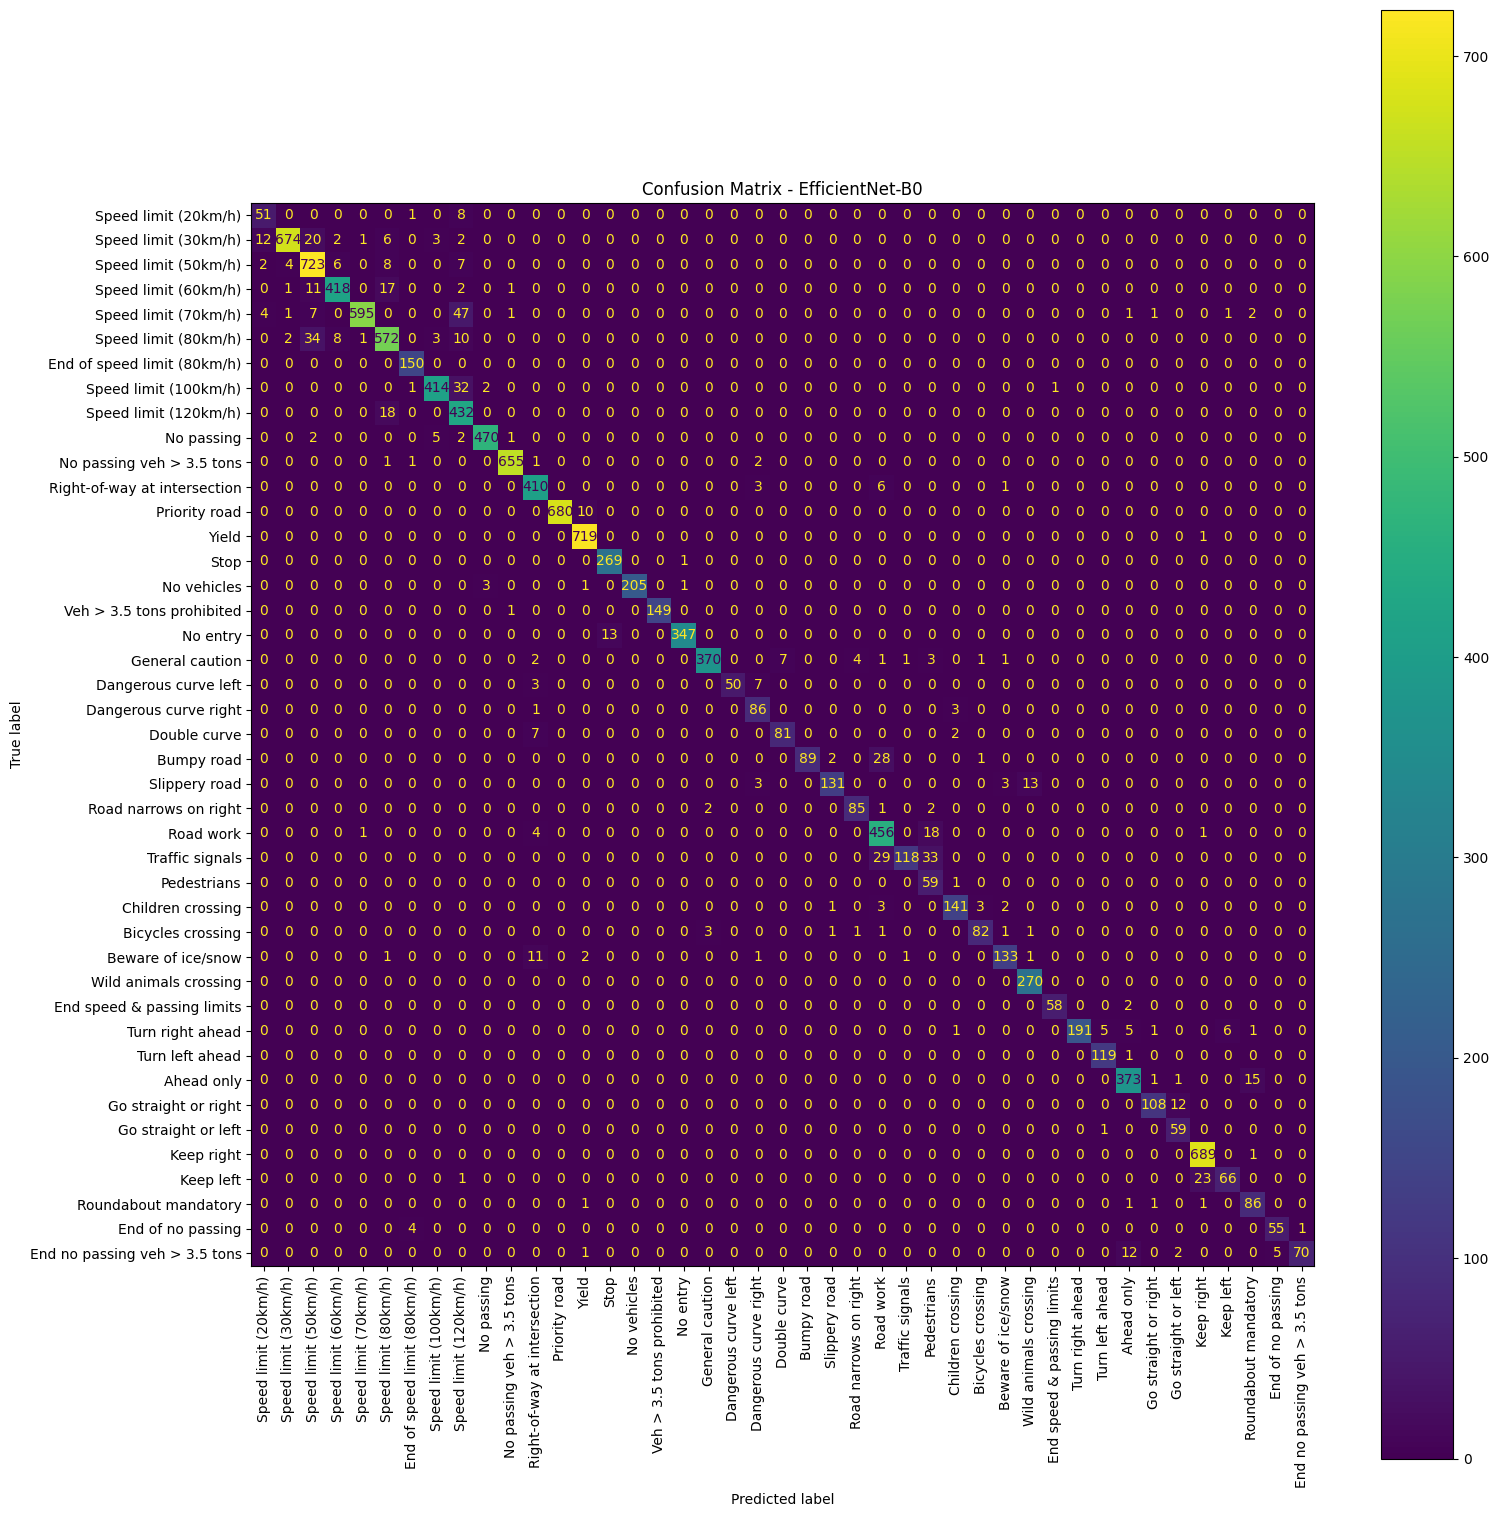

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 16))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_names.values())
)

disp.plot(
    xticks_rotation="vertical",
    values_format="d",
    ax=plt.gca()
)

plt.title("Confusion Matrix - EfficientNet-B0")
plt.tight_layout()
plt.show()

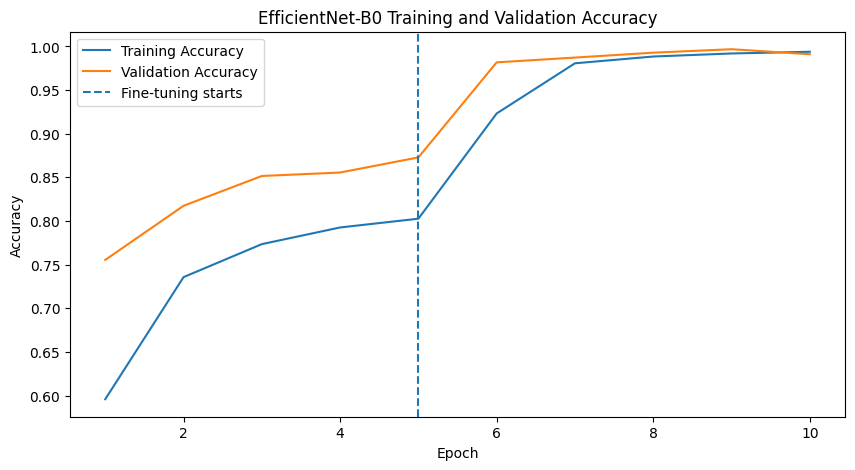

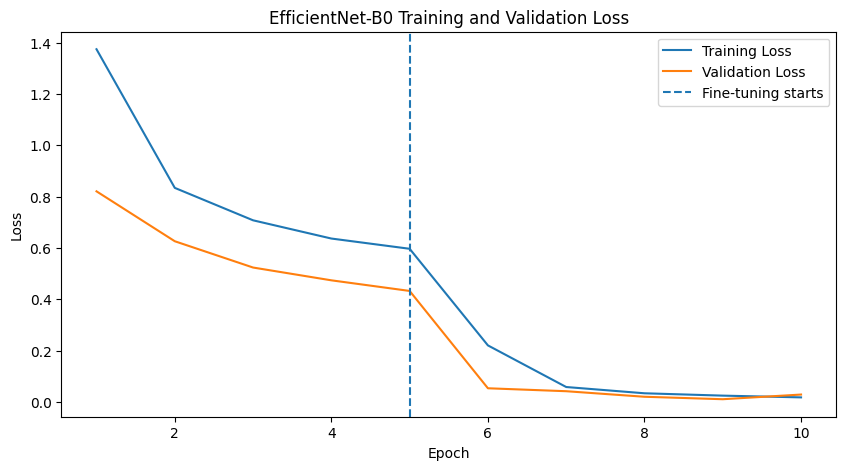

In [34]:
import matplotlib.pyplot as plt

train_acc = history.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]

train_loss = history.history["loss"] + history_ft.history["loss"]
val_loss = history.history["val_loss"] + history_ft.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.axvline(x=5, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.axvline(x=5, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.legend()
plt.show()

## 9. Save the Trained Model

The trained EfficientNet-B0 model is saved in Keras format so that it can be reused later without retraining from scratch.

In [36]:
model.save("/kaggle/working/efficientnet_b0_gtsrb.keras")

print("Model saved successfully.")

Model saved successfully.


## 10. Sample Prediction

A test image is selected to demonstrate the model's prediction.

The predicted traffic sign class is compared with the actual class, along with the model's confidence.

2026-09-18 11:29:36.698855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:29:36.836249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:29:37.711229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 11:29:37.848570: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


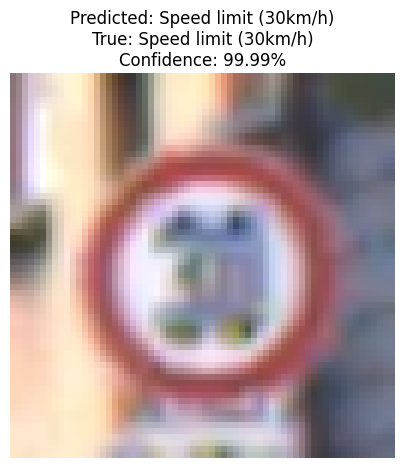

Predicted class: Speed limit (30km/h)
True class: Speed limit (30km/h)
Confidence: 99.99%


In [37]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Select one test image
index = 100

image_path = os.path.join(DATASET_DIR, test_paths[index])
true_label = test_labels[index]

# Load and preprocess image
image = tf.io.read_file(image_path)
image = tf.image.decode_png(image, channels=3)
image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
image = tf.cast(image, tf.float32)

# Add batch dimension
input_image = tf.expand_dims(image, axis=0)

# Prediction
prediction = model.predict(input_image, verbose=0)
predicted_label = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

# Display
plt.figure(figsize=(5, 5))
plt.imshow(image.numpy().astype("uint8"))
plt.axis("off")
plt.title(
    f"Predicted: {class_names[predicted_label]}\n"
    f"True: {class_names[true_label]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("Predicted class:", class_names[predicted_label])
print("True class:", class_names[true_label])
print("Confidence:", f"{confidence:.2f}%")

## 11. Results and Conclusion

The final model achieved **94.68% accuracy on the unseen GTSRB test set**.

The classification report shows strong overall precision, recall, and F1-score, while the confusion matrix helps identify traffic sign classes that are more difficult to distinguish.

The project demonstrates how transfer learning and fine-tuning with EfficientNet-B0 can be used for traffic sign recognition.